In [ ]:
# Tarea 1: Procesamiento y Clasificación de Datos

In [8]:
# Librerías

from pathlib import Path
from collections import Counter
import re
import unicodedata
import string

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [14]:
# Rutas de los archivos de texto

ruta_capitulo_1 = Path(
    r"C:\Users\irwin\Downloads\Capitulo_1.txt"
)

ruta_capitulo_2 = Path(
    r"C:\Users\irwin\Downloads\Capitulo_2.txt"
)


# Comprobar que existan
print("Capítulo 1 encontrado:", ruta_capitulo_1.exists())
print("Capítulo 2 encontrado:", ruta_capitulo_2.exists())


Capítulo 1 encontrado: True
Capítulo 2 encontrado: True


In [ ]:
# Leer los archivos de texto

def leer_archivo(ruta):
    """
    Lee un archivo probando diferentes codificaciones.
    """

    codificaciones = [
        "utf-8",
        "utf-8-sig",
        "cp1252",
        "latin-1"
    ]

    for codificacion in codificaciones:
        try:
            return ruta.read_text(encoding=codificacion)
        except UnicodeDecodeError:
            continue

    raise ValueError(
        f"No fue posible leer el archivo: {ruta}"
    )

# Crear el diccionario textos
textos = {
    "Capítulo 1": leer_archivo(ruta_capitulo_1),
    "Capítulo 2": leer_archivo(ruta_capitulo_2)
}


print("\nArchivos cargados:")
print(textos.keys())        


Archivos cargados:
dict_keys(['Capítulo 1', 'Capítulo 2'])


In [18]:
# STOPWORDS EN ESPAÑOL

stopwords_es = {
    "a", "acá", "ahí", "al", "algo", "algunas", "algunos",
    "ante", "antes", "aquel", "aquella", "aquellas", "aquello",
    "aquellos", "aquí", "así", "aunque", "bajo", "bien", "cada",
    "casi", "como", "con", "contra", "cual", "cuando", "de",
    "del", "desde", "donde", "dos", "durante", "e", "el",
    "ella", "ellas", "ellos", "en", "entre", "era", "eran",
    "es", "esa", "esas", "ese", "eso", "esos", "esta",
    "estaba", "estaban", "estado", "estar", "estas", "este",
    "esto", "estos", "fue", "fuera", "fueron", "ha", "había",
    "han", "hasta", "hay", "la", "las", "le", "les", "lo",
    "los", "más", "me", "mi", "mientras", "muy", "ni", "no",
    "nos", "o", "otra", "otras", "otro", "otros", "para",
    "pero", "poco", "por", "porque", "que", "qué", "se",
    "ser", "si", "sí", "sin", "sobre", "son", "su", "sus",
    "también", "tan", "te", "tenía", "tiene", "todo", "todos",
    "tu", "un", "una", "uno", "unos", "usted", "ya", "y", "yo"
}

In [23]:
# Limpiar espacios y saltos de línea

def limpiar_espacios(texto):

    texto = texto.replace("\xa0", " ")

    texto = re.sub(
        r"[ \t]+",
        " ",
        texto
    )

    texto = re.sub(
        r"\n{3,}",
        "\n\n",
        texto
    )

    return texto.strip()

for nombre in textos:

    textos[nombre] = limpiar_espacios(
        textos[nombre]
    )


In [25]:
# Separar el texto en palabras

def tokenizar(texto):

    patron = r"[A-Za-zÁÉÍÓÚÜÑáéíóúüñ]+"

    palabras = re.findall(
        patron,
        texto.lower()
    )

    return palabras

palabras_prueba = tokenizar(
    textos["Capítulo 1"]
)

print(palabras_prueba[:20])

['el', 'niño', 'que', 'vivió', 'el', 'señor', 'y', 'la', 'señora', 'dursley', 'que', 'vivían', 'en', 'el', 'número', 'de', 'privet', 'drive', 'estaban', 'orgullosos']


In [ ]:
# Eliminar acentos y caracteres especiales

def quitar_acentos(palabra):

    palabra_normalizada = unicodedata.normalize(
        "NFD",
        palabra
    )

    palabra_sin_acentos = "".join(
        caracter
        for caracter in palabra_normalizada
        if unicodedata.category(caracter) != "Mn"
    )

    return palabra_sin_acentos

print(quitar_acentos("había"))
print(quitar_acentos("capítulo"))

habia
capitulo


In [ ]:
# Normalizar palabras

def normalizar_palabras(
    texto,
    eliminar_stopwords=False
):

    palabras = tokenizar(texto)

    palabras = [
        quitar_acentos(palabra)
        for palabra in palabras
    ]

    if eliminar_stopwords:

        stopwords_normalizadas = {
            quitar_acentos(palabra)
            for palabra in stopwords_es
        }

        palabras = [
            palabra
            for palabra in palabras
            if palabra not in stopwords_normalizadas
            and len(palabra) > 2
        ]

    return palabras

palabras_limpias = normalizar_palabras(
    textos["Capítulo 1"],
    eliminar_stopwords=True
)

print(palabras_limpias[:20])

['nino', 'vivio', 'senor', 'senora', 'dursley', 'vivian', 'numero', 'privet', 'drive', 'orgullosos', 'decir', 'normales', 'afortunadamente', 'ultimas', 'personas', 'esperaria', 'encontrar', 'relacionadas', 'extrano', 'misterioso']


In [31]:
# Dividir en oraciones 

def dividir_oraciones(texto):

    oraciones = re.split(
        r"(?<=[.!?])\s+",
        texto
    )

    oraciones = [
        oracion.strip()
        for oracion in oraciones
        if oracion.strip()
    ]

    return oraciones

oraciones_capitulo_1 = dividir_oraciones(
    textos["Capítulo 1"]
)

print("Número de oraciones:")
print(len(oraciones_capitulo_1))

Número de oraciones:
416


In [32]:
# Función de estadísticas descriptivas

def calcular_estadisticas(nombre, texto):

    palabras = normalizar_palabras(texto)

    palabras_unicas = set(palabras)

    oraciones = dividir_oraciones(texto)

    parrafos = [
        parrafo
        for parrafo in texto.split("\n\n")
        if parrafo.strip()
    ]

    longitud_palabras = [
        len(palabra)
        for palabra in palabras
    ]

    palabras_por_oracion = [
        len(tokenizar(oracion))
        for oracion in oraciones
        if len(tokenizar(oracion)) > 0
    ]

    serie_longitud = pd.Series(
        longitud_palabras,
        dtype="float64"
    )

    total_palabras = len(palabras)

    total_unicas = len(
        palabras_unicas
    )

    riqueza_lexica = (
        total_unicas / total_palabras
        if total_palabras > 0
        else 0
    )

    return {
        "Documento": nombre,
        "Caracteres con espacios": len(texto),
        "Caracteres sin espacios": len(
            re.sub(r"\s", "", texto)
        ),
        "Número de párrafos": len(parrafos),
        "Número de oraciones": len(oraciones),
        "Palabras totales": total_palabras,
        "Palabras únicas": total_unicas,
        "Riqueza léxica": riqueza_lexica,
        "Longitud media de palabra": serie_longitud.mean(),
        "Mediana longitud de palabra": serie_longitud.median(),
        "Desviación longitud palabra": serie_longitud.std(),
        "Palabra más corta": serie_longitud.min(),
        "Palabra más larga": serie_longitud.max(),
        "Promedio palabras por oración": (
            sum(palabras_por_oracion)
            / len(palabras_por_oracion)
            if palabras_por_oracion
            else 0
        ),
        "Mínimo palabras por oración": min(
            palabras_por_oracion,
            default=0
        ),
        "Máximo palabras por oración": max(
            palabras_por_oracion,
            default=0
        )
    }
    

In [34]:
# Crear tabla descriptiva

resultados_descriptivos = []

for nombre, texto in textos.items():

    estadisticas = calcular_estadisticas(
        nombre,
        texto
    )

    resultados_descriptivos.append(
        estadisticas
    )

df_estadisticas = pd.DataFrame(
    resultados_descriptivos
)

df_estadisticas

,Documento,Caracteres con espacios,Caracteres sin espacios,Número de párrafos,Número de oraciones,Palabras totales,Palabras únicas,Riqueza léxica,Longitud media de palabra,Mediana longitud de palabra,Desviación longitud palabra,Palabra más corta,Palabra más larga,Promedio palabras por oración,Mínimo palabras por oración,Máximo palabras por oración
0,Capítulo 1,27599,22849,1,416,4749,1323,0.278585,4.585176,4.0,2.568964,1.0,15.0,11.415865,1,51
1,Capítulo 2,20183,16642,1,264,3530,1078,0.305382,4.518980,4.0,2.484479,1.0,15.0,13.422053,1,67


In [35]:
# Redondear los resultados

columnas_decimales = [
    "Riqueza léxica",
    "Longitud media de palabra",
    "Mediana longitud de palabra",
    "Desviación longitud palabra",
    "Promedio palabras por oración"
]

df_estadisticas[columnas_decimales] = (
    df_estadisticas[columnas_decimales]
    .round(3)
)

df_estadisticas

,Documento,Caracteres con espacios,Caracteres sin espacios,Número de párrafos,Número de oraciones,Palabras totales,Palabras únicas,Riqueza léxica,Longitud media de palabra,Mediana longitud de palabra,Desviación longitud palabra,Palabra más corta,Palabra más larga,Promedio palabras por oración,Mínimo palabras por oración,Máximo palabras por oración
0,Capítulo 1,27599,22849,1,416,4749,1323,0.279,4.585,4.0,2.569,1.0,15.0,11.416,1,51
1,Capítulo 2,20183,16642,1,264,3530,1078,0.305,4.519,4.0,2.484,1.0,15.0,13.422,1,67


In [36]:
# Frecuencia de palabras

frecuencias = {}

for nombre, texto in textos.items():

    palabras_limpias = normalizar_palabras(
        texto,
        eliminar_stopwords=True
    )

    contador = Counter(
        palabras_limpias
    )

    frecuencias[nombre] = contador

    df_frecuencia = pd.DataFrame(
        contador.most_common(20),
        columns=[
            "Palabra",
            "Frecuencia"
        ]
    )

    print("\n" + nombre)

    display(df_frecuencia)


Capítulo 1


,Palabra,Frecuencia
0,dursley,53
1,dumbledore,36
2,senor,33
3,profesora,28
4,dijo,26
5,mcgonagall,25
6,senora,22
7,gato,22
8,potter,20
9,harry,18



Capítulo 2


,Palabra,Frecuencia
0,harry,78
1,dudley,52
2,tia,25
3,petunia,21
4,vernon,20
5,podia,18
6,tio,18
7,dursley,16
8,dijo,16
9,serpiente,14


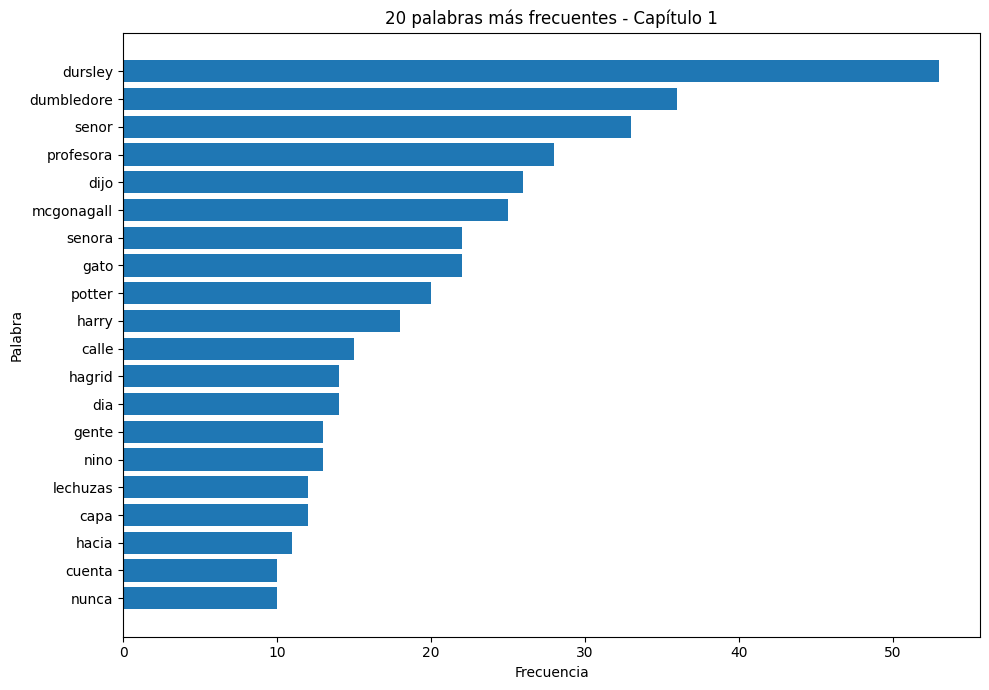

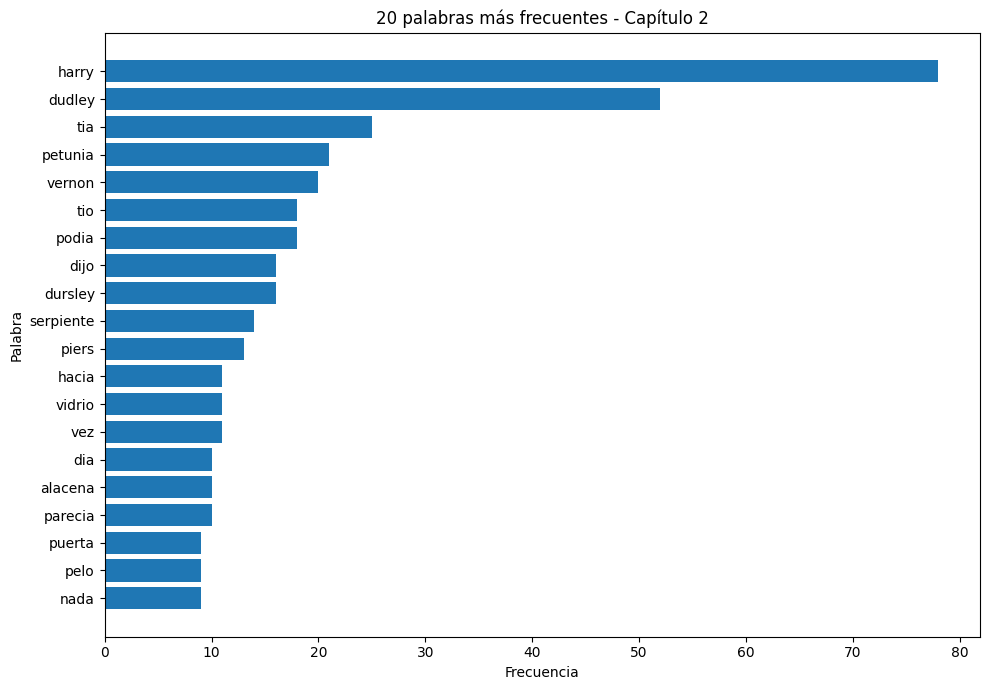

In [37]:
# Gráficas de frecuencia de palabras

for nombre, contador in frecuencias.items():

    datos = pd.DataFrame(
        contador.most_common(20),
        columns=[
            "Palabra",
            "Frecuencia"
        ]
    )

    datos = datos.sort_values(
        "Frecuencia",
        ascending=True
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        datos["Palabra"],
        datos["Frecuencia"]
    )

    plt.title(
        f"20 palabras más frecuentes - {nombre}"
    )

    plt.xlabel("Frecuencia")
    plt.ylabel("Palabra")

    plt.tight_layout()
    plt.show()

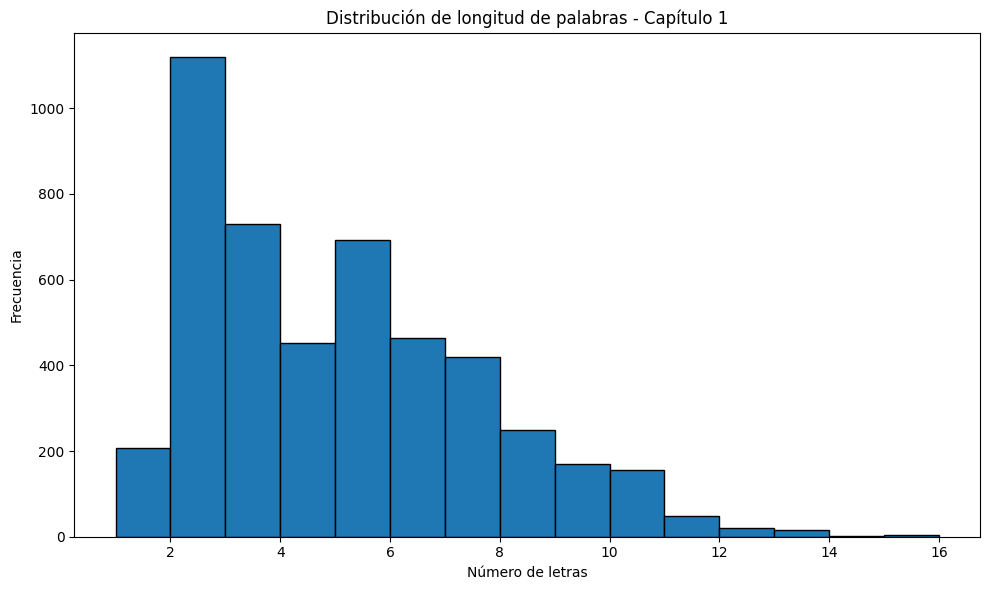

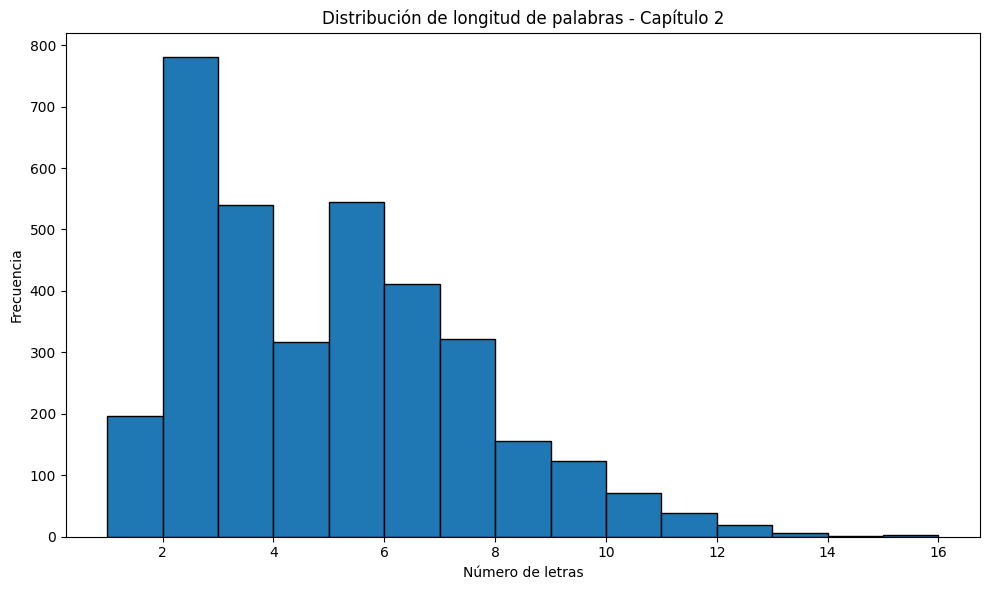

In [38]:
# Distribución de longitud de palabras 

for nombre, texto in textos.items():

    palabras = normalizar_palabras(texto)

    longitudes = [
        len(palabra)
        for palabra in palabras
    ]

    plt.figure(figsize=(10, 6))

    plt.hist(
        longitudes,
        bins=range(
            1,
            max(longitudes) + 2
        ),
        edgecolor="black"
    )

    plt.title(
        f"Distribución de longitud de palabras - {nombre}"
    )

    plt.xlabel("Número de letras")
    plt.ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

In [39]:
# Crear n-gramas

def crear_ngramas(palabras, n):

    return [
        " ".join(
            palabras[i:i+n]
        )
        for i in range(
            len(palabras) - n + 1
        )
    ]

In [40]:
# Biagramas y trigramas

for nombre, texto in textos.items():

    palabras = normalizar_palabras(
        texto,
        eliminar_stopwords=True
    )

    bigramas = Counter(
        crear_ngramas(
            palabras,
            2
        )
    )

    trigramas = Counter(
        crear_ngramas(
            palabras,
            3
        )
    )

    df_bigramas = pd.DataFrame(
        bigramas.most_common(15),
        columns=[
            "Bigrama",
            "Frecuencia"
        ]
    )

    df_trigramas = pd.DataFrame(
        trigramas.most_common(15),
        columns=[
            "Trigrama",
            "Frecuencia"
        ]
    )

    print("\n" + "=" * 50)
    print(nombre)
    print("=" * 50)

    print("\nBigramas:")
    display(df_bigramas)

    print("\nTrigramas:")
    display(df_trigramas)


Capítulo 1

Bigramas:


,Bigrama,Frecuencia
0,senor dursley,27
1,profesora mcgonagall,25
2,senora dursley,19
3,privet drive,8
4,dijo dumbledore,7
5,darse cuenta,6
6,quien sabe,5
7,estrellas fugaces,5
8,dursley quedo,4
9,harry potter,4



Trigramas:


,Trigrama,Frecuencia
0,senor dursley quedo,3
1,senor senora dursley,2
2,tenian hijo pequeno,2
3,potter tenian hijo,2
4,senor dursley dio,2
5,dursley dio cuenta,2
6,esquina privet drive,2
7,sentado pared jardin,2
8,dijo senor dursley,2
9,senor dursley pregunto,2



Capítulo 2

Bigramas:


,Bigrama,Frecuencia
0,tia petunia,21
1,tio vernon,18
2,dudley piers,6
3,diez anos,5
4,senora figg,5
5,dudley parecia,4
6,harry podia,4
7,dijo harry,4
8,cumpleanos dudley,3
9,tal vez,3



Trigramas:


,Trigrama,Frecuencia
0,decia menudo dudley,2
1,menudo dudley parecia,2
2,dijo tia petunia,2
3,tia petunia dudley,2
4,harry tio vernon,2
5,coche tio vernon,2
6,tio vernon golpeo,2
7,tio vernon dudley,2
8,vidrio desvanecio habian,1
9,desvanecio habian pasado,1


In [41]:
# Signos de puntuación

signos = {
    "Punto": ".",
    "Coma": ",",
    "Punto y coma": ";",
    "Dos puntos": ":",
    "Interrogación inicial": "¿",
    "Interrogación final": "?",
    "Exclamación inicial": "¡",
    "Exclamación final": "!",
    "Comillas iniciales": "«",
    "Comillas finales": "»",
    "Raya de diálogo": "—",
    "Paréntesis inicial": "(",
    "Paréntesis final": ")"
}

In [42]:
# Tabla de frecuencia de signos de puntuación

resultados_puntuacion = []

for nombre, texto in textos.items():

    for nombre_signo, simbolo in signos.items():

        frecuencia = texto.count(
            simbolo
        )

        resultados_puntuacion.append({
            "Documento": nombre,
            "Signo": nombre_signo,
            "Símbolo": simbolo,
            "Frecuencia": frecuencia
        })


df_puntuacion = pd.DataFrame(
    resultados_puntuacion
)

df_puntuacion

,Documento,Signo,Símbolo,Frecuencia
0,Capítulo 1,Punto,.,489
1,Capítulo 1,Coma,",",266
2,Capítulo 1,Punto y coma,;,4
3,Capítulo 1,Dos puntos,:,11
4,Capítulo 1,Interrogación inicial,¿,37
5,Capítulo 1,Interrogación final,?,37
6,Capítulo 1,Exclamación inicial,¡,22
7,Capítulo 1,Exclamación final,!,22
8,Capítulo 1,Comillas iniciales,«,7
9,Capítulo 1,Comillas finales,»,7


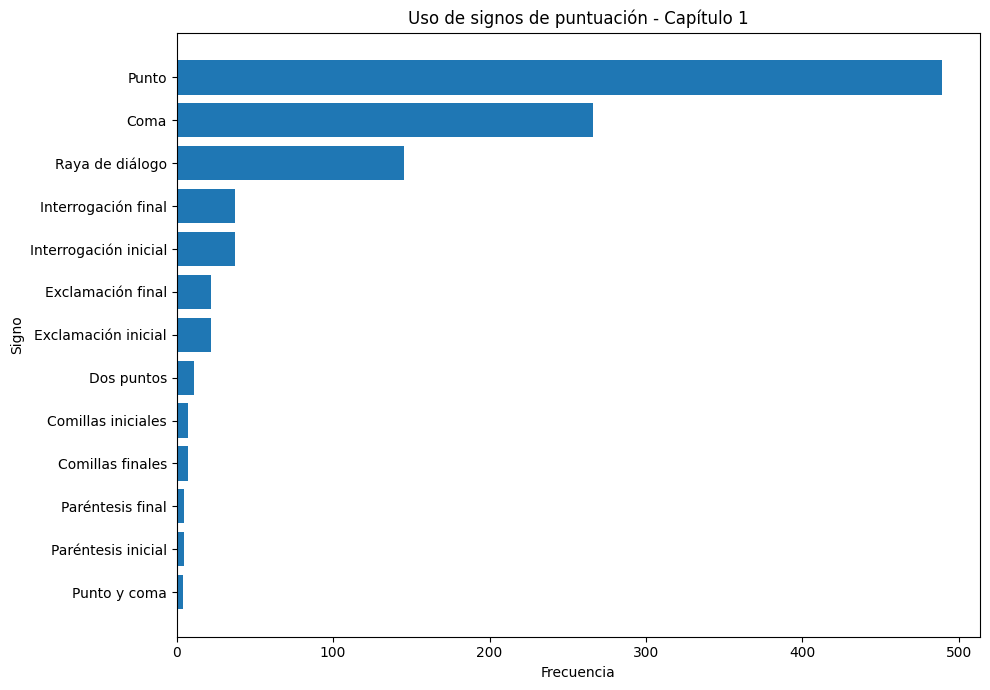

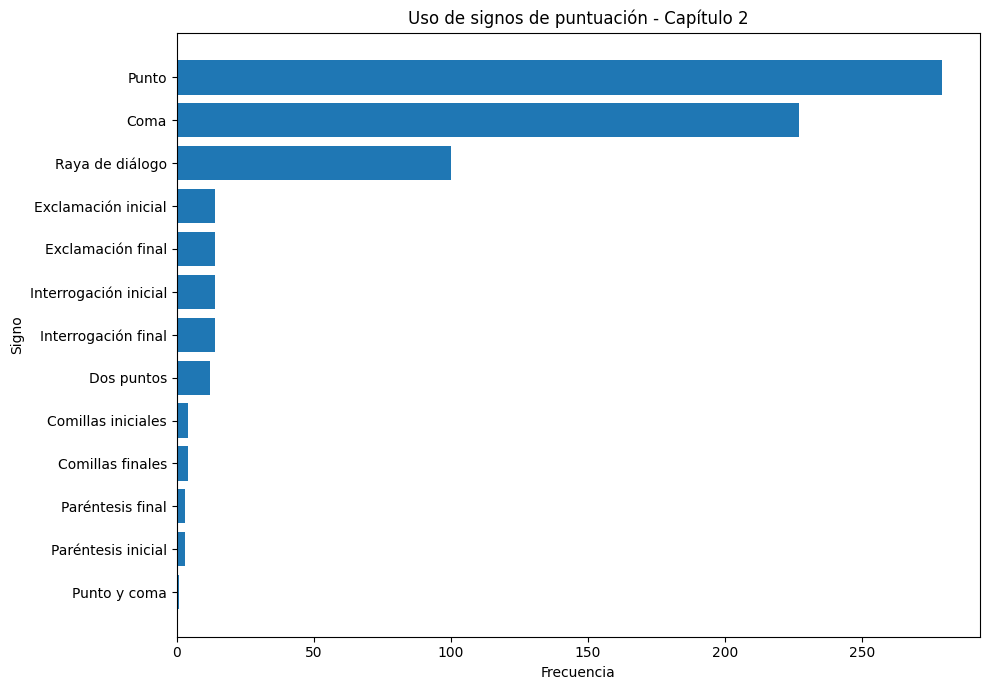

In [43]:
# graficas de punticación

for nombre in df_puntuacion["Documento"].unique():

    datos = df_puntuacion[
        df_puntuacion["Documento"] == nombre
    ]

    datos = datos.sort_values(
        "Frecuencia",
        ascending=True
    )

    plt.figure(figsize=(10, 7))

    plt.barh(
        datos["Signo"],
        datos["Frecuencia"]
    )

    plt.title(
        f"Uso de signos de puntuación - {nombre}"
    )

    plt.xlabel("Frecuencia")
    plt.ylabel("Signo")

    plt.tight_layout()
    plt.show()